# Lab: Transfer Learning for Image Classification with PyTorch

## Lab overview
In this lab, we will use **transfer learning** to solve an image classification problem with a **pretrained ResNet18** model in PyTorch.

### Dataset
We use **CIFAR-10**, which contains 10 image classes:
- airplane
- automobile
- bird
- cat
- deer
- dog
- frog
- horse
- ship
- truck

### Learning goals
By the end of the lab, you should be able to:
1. understand what transfer learning means,
2. prepare an image dataset for a pretrained model,
3. replace the final classification layer,
4. train only the classifier while freezing the backbone,
5. evaluate the model using accuracy and a confusion matrix,
6. visualize both the dataset and model predictions,
7. optionally fine-tune part of the pretrained model and compare results.

### Notes
- The code is written to be **simple and readable**.
- Each section starts with a **task/question** so the notebook is easy to follow.
- The notebook uses **Python packages only**, mainly `torch`, `torchvision`, `matplotlib`, and `scikit-learn`.

## Task 1 — Import the required Python packages

**Question:**  
Which Python libraries do we need for transfer learning, image loading, training, evaluation, and visualization?

**What to do:**  
Import the required packages and set a random seed for reproducibility.

In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset

from torchvision import datasets, transforms, models
from torchvision.models import ResNet18_Weights

from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


## Task 2 — Understand the dataset before training

**Question:**  
What does the dataset look like? How many classes are there, and what kinds of images are included?

**What to do:**  
Load CIFAR-10 in a simple way first and visualize a few sample images.  
This step is useful because you should always inspect the data before training a model.

In [2]:
basic_transform = transforms.ToTensor()

train_preview = datasets.CIFAR10(root="./data", train=True, download=True, transform=basic_transform)
test_preview = datasets.CIFAR10(root="./data", train=False, download=True, transform=basic_transform)

class_names = train_preview.classes
print("Classes:", class_names)
print("Number of training images:", len(train_preview))
print("Number of test images:", len(test_preview))

100%|██████████| 170M/170M [00:01<00:00, 85.3MB/s]


Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Number of training images: 50000
Number of test images: 10000


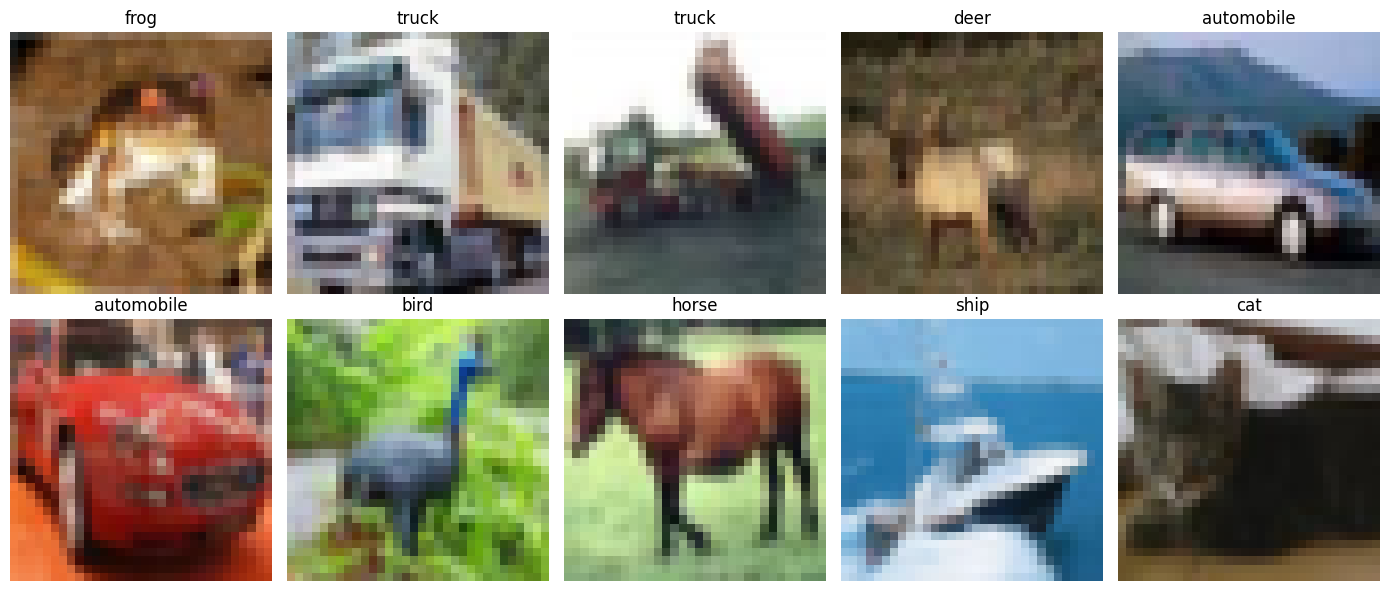

In [3]:
def show_images(dataset, class_names, rows=2, cols=5):
    plt.figure(figsize=(14, 6))
    for i in range(rows * cols):
        image, label = dataset[i]
        image_np = image.permute(1, 2, 0).numpy()
        plt.subplot(rows, cols, i + 1)
        plt.imshow(image_np)
        plt.title(class_names[label])
        plt.axis("off")
    plt.tight_layout()
    plt.show()

show_images(train_preview, class_names)

## Task 3 — Prepare the data for transfer learning

**Question:**  
Why do we need different preprocessing for a pretrained model?

**Hint:**  
A pretrained ResNet18 was trained on ImageNet, so it expects:
- RGB images,
- a larger image size than CIFAR-10,
- normalization values suitable for ImageNet.

**What to do:**  
Create training and test transforms, then build dataloaders.

In [4]:
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std)
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std)
])

train_dataset = datasets.CIFAR10(root="./data", train=True, download=True, transform=train_transform)
test_dataset = datasets.CIFAR10(root="./data", train=False, download=True, transform=test_transform)

train_indices = list(range(5000))
test_indices = list(range(1000))

train_subset = Subset(train_dataset, train_indices)
test_subset = Subset(test_dataset, test_indices)

batch_size = 32

train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True, num_workers=2)
test_loader = DataLoader(test_subset, batch_size=batch_size, shuffle=False, num_workers=2)

print("Training batches:", len(train_loader))
print("Test batches:", len(test_loader))

Training batches: 157
Test batches: 32


## Task 4 — Visualize preprocessed data in an understandable way

**Question:**  
After normalization, the images are no longer directly human-friendly to display.  
How can we convert them back for visualization?

**What to do:**  
Take a batch from the dataloader, undo the normalization, and display a few images.

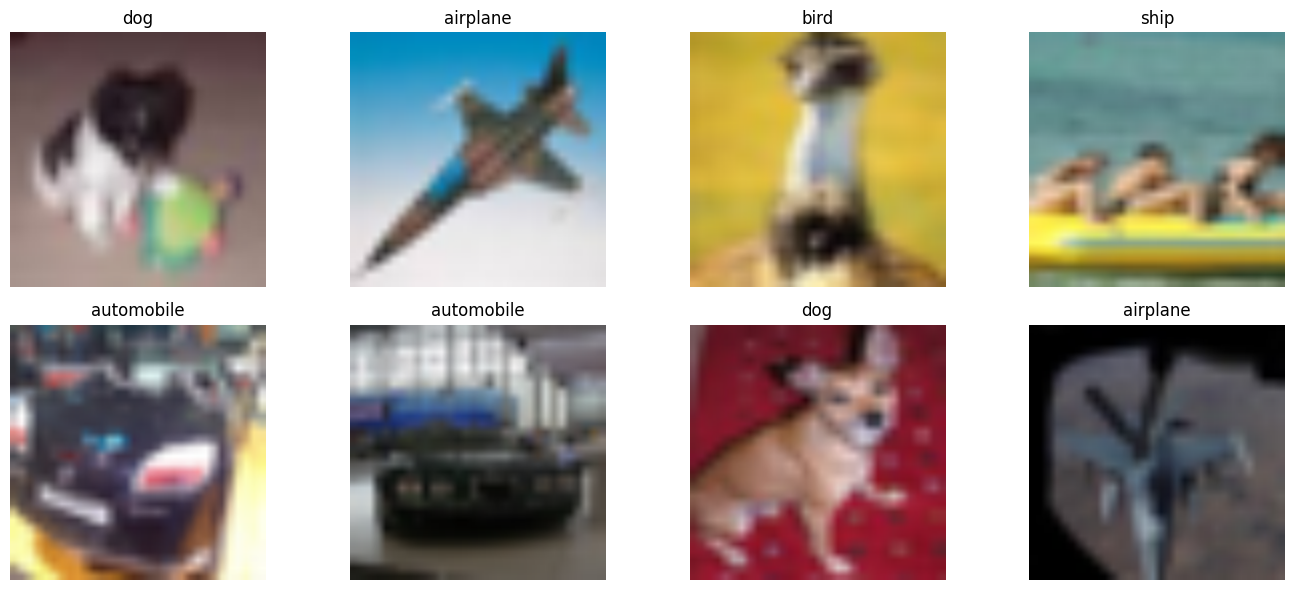

In [5]:
def denormalize(image_tensor, mean, std):
    image = image_tensor.clone().cpu()
    for c in range(3):
        image[c] = image[c] * std[c] + mean[c]
    image = torch.clamp(image, 0, 1)
    return image

images, labels = next(iter(train_loader))

plt.figure(figsize=(14, 6))
for i in range(8):
    img = denormalize(images[i], imagenet_mean, imagenet_std)
    img_np = img.permute(1, 2, 0).numpy()
    plt.subplot(2, 4, i + 1)
    plt.imshow(img_np)
    plt.title(class_names[labels[i].item()])
    plt.axis("off")
plt.tight_layout()
plt.show()

## Task 5 — Load a pretrained model and adapt it to CIFAR-10

**Question:**  
What changes are needed to use a pretrained ImageNet model for a new classification task?

**What to do:**  
1. Load a pretrained **ResNet18**.  
2. Freeze the backbone so only the final classifier is trained.  
3. Replace the last fully connected layer with a new layer for **10 CIFAR-10 classes**.

This is the core idea of **transfer learning**.

In [6]:
weights = ResNet18_Weights.DEFAULT
model = models.resnet18(weights=weights)

for param in model.parameters():
    param.requires_grad = False

num_features = model.fc.in_features
model.fc = nn.Linear(num_features, len(class_names))

model = model.to(device)
print(model)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 141MB/s]

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

## Task 6 — Define loss function and optimizer

**Question:**  
Why do we only pass some model parameters to the optimizer?

**Answer idea:**  
Because we froze the pretrained backbone. Only the new classifier layer should be updated.

**What to do:**  
Use cross-entropy loss and Adam optimizer.

In [7]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)

## Task 7 — Train the transfer learning model

**Question:**  
Train the model for a few epochs and observe whether the training loss decreases and the accuracy improves.

**What to do:**  
Run a simple training loop.  
Keep the code readable and print progress clearly.

In [8]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc


def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    all_labels = []
    all_preds = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(predicted.cpu().numpy())

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc, all_labels, all_preds

In [9]:
num_epochs = 3

history = {
    "train_loss": [],
    "train_acc": [],
    "test_loss": [],
    "test_acc": []
}

for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    test_loss, test_acc, y_true, y_pred = evaluate(model, test_loader, criterion, device)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["test_loss"].append(test_loss)
    history["test_acc"].append(test_acc)

    print(f"Epoch {epoch+1}/{num_epochs}")
    print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"  Test  Loss: {test_loss:.4f} | Test  Acc: {test_acc:.4f}")

Epoch 1/3
  Train Loss: 1.4441 | Train Acc: 0.5472
  Test  Loss: 0.9797 | Test  Acc: 0.7160
Epoch 2/3
  Train Loss: 0.8746 | Train Acc: 0.7346
  Test  Loss: 0.7964 | Test  Acc: 0.7500
Epoch 3/3
  Train Loss: 0.7446 | Train Acc: 0.7596
  Test  Loss: 0.7462 | Test  Acc: 0.7500


## Task 8 — Visualize the learning progress

**Question:**  
How do training and test performance change over epochs?

**What to do:**  
Plot:
1. training and test loss,
2. training and test accuracy.

This helps you interpret whether the model is learning.

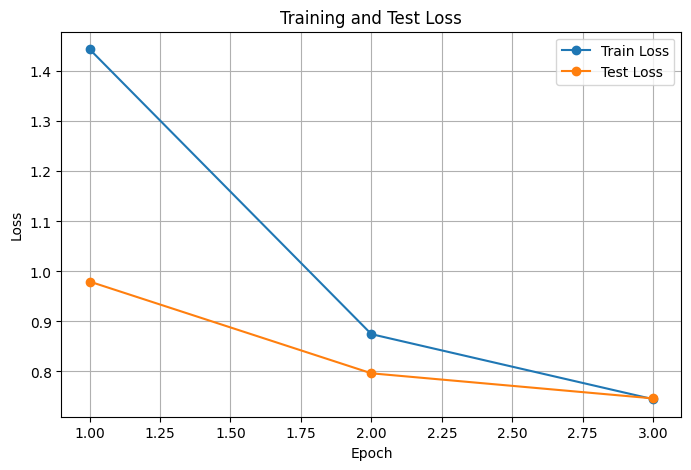

In [10]:
epochs = range(1, num_epochs + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, history["train_loss"], marker="o", label="Train Loss")
plt.plot(epochs, history["test_loss"], marker="o", label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Test Loss")
plt.legend()
plt.grid(True)
plt.show()

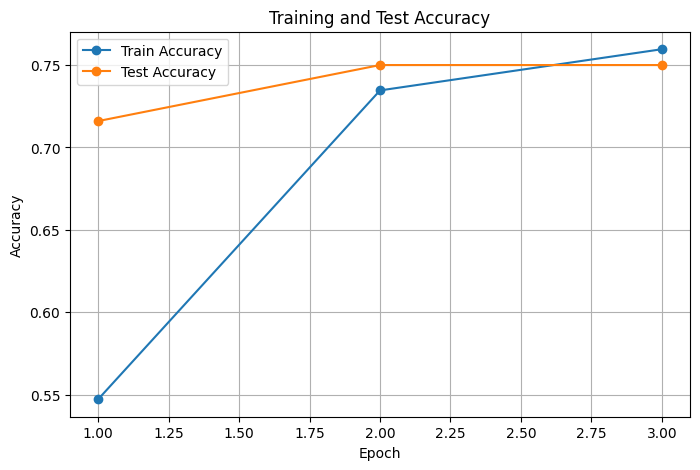

In [11]:
plt.figure(figsize=(8, 5))
plt.plot(epochs, history["train_acc"], marker="o", label="Train Accuracy")
plt.plot(epochs, history["test_acc"], marker="o", label="Test Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Test Accuracy")
plt.legend()
plt.grid(True)
plt.show()

## Task 9 — Evaluate the model using a confusion matrix

**Question:**  
Which classes are recognized well, and which classes are often confused?

**What to do:**  
Compute a confusion matrix and display it.

In [1]:
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

fig, ax = plt.subplots(figsize=(10, 10))
disp.plot(ax=ax, xticks_rotation=45, colorbar=False)
plt.title("Confusion Matrix")
plt.show()

NameError: name 'confusion_matrix' is not defined

## Task 10 — Print a classification report

**Question:**  
How can we see precision, recall, and F1-score for each class?

**What to do:**  
Generate a classification report.

In [1]:
print(classification_report(y_true, y_pred, target_names=class_names))

NameError: name 'classification_report' is not defined

## Task 11 — Visualize model predictions on test images

**Question:**  
Can we inspect example predictions to better understand where the model succeeds or fails?

**What to do:**  
Display a few test images with:
- true label,
- predicted label.

In [ ]:
def show_predictions(model, loader, class_names, mean, std, device, num_images=8):
    model.eval()
    images_shown = 0

    plt.figure(figsize=(14, 6))

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            for i in range(images.size(0)):
                if images_shown >= num_images:
                    plt.tight_layout()
                    plt.show()
                    return

                img = denormalize(images[i], mean, std)
                img_np = img.permute(1, 2, 0).cpu().numpy()

                plt.subplot(2, 4, images_shown + 1)
                plt.imshow(img_np)
                plt.title(f"True: {class_names[labels[i].item()]}\nPred: {class_names[preds[i].item()]}")
                plt.axis("off")
                images_shown += 1

show_predictions(model, test_loader, class_names, imagenet_mean, imagenet_std, device)

## Task 12 — Fine-tuning extension (optional)

**Question:**  
What happens if we unfreeze part of the pretrained model and train a little more?

**What to do:**  
Unfreeze the last residual block and compare the results with the pure feature-extraction approach.

**Why this matters:**  
This helps you understand the difference between:
- **feature extraction**: only the last layer is trained,
- **fine-tuning**: some pretrained layers are also updated.

In [ ]:
finetune_model = models.resnet18(weights=weights)

for param in finetune_model.parameters():
    param.requires_grad = False

for param in finetune_model.layer4.parameters():
    param.requires_grad = True

num_features = finetune_model.fc.in_features
finetune_model.fc = nn.Linear(num_features, len(class_names))

finetune_model = finetune_model.to(device)

finetune_criterion = nn.CrossEntropyLoss()
finetune_optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, finetune_model.parameters()),
    lr=0.0001
)

finetune_history = {
    "train_loss": [],
    "train_acc": [],
    "test_loss": [],
    "test_acc": []
}

finetune_epochs = 2

for epoch in range(finetune_epochs):
    train_loss, train_acc = train_one_epoch(finetune_model, train_loader, finetune_criterion, finetune_optimizer, device)
    test_loss, test_acc, ft_y_true, ft_y_pred = evaluate(finetune_model, test_loader, finetune_criterion, device)

    finetune_history["train_loss"].append(train_loss)
    finetune_history["train_acc"].append(train_acc)
    finetune_history["test_loss"].append(test_loss)
    finetune_history["test_acc"].append(test_acc)

    print(f"Fine-tuning Epoch {epoch+1}/{finetune_epochs}")
    print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"  Test  Loss: {test_loss:.4f} | Test  Acc: {test_acc:.4f}")

## Task 13 — Compare feature extraction and fine-tuning

**Question:**  
Which approach performs better in this lab:
1. training only the final layer, or  
2. fine-tuning the last residual block as well?

**What to do:**  
Print and compare final test accuracies.

In [ ]:
print("Final test accuracy (feature extraction only):", history["test_acc"][-1])
print("Final test accuracy (fine-tuning):", finetune_history["test_acc"][-1])

## Self Reflection questions

1. What is transfer learning in your own words?  
2. Why is a pretrained model useful when the dataset is relatively small?  
3. Why did we resize CIFAR-10 images to 224×224?  
4. What is the difference between freezing the backbone and fine-tuning it?  
5. Which classes seemed easiest to classify? Which were harder?  
6. Based on the confusion matrix, which classes were often mixed up and why?  
7. Did fine-tuning improve the result? Why might that happen?  
8. What would you try next to improve the model further?

